Part 1: Creating make_blobs Dataset
X shape: (1000, 2)
y shape: (1000,)
Number of classes: 4
  Class 0: 250 samples
  Class 1: 250 samples
  Class 2: 250 samples
  Class 3: 250 samples

Part 2: Visualizing the Data


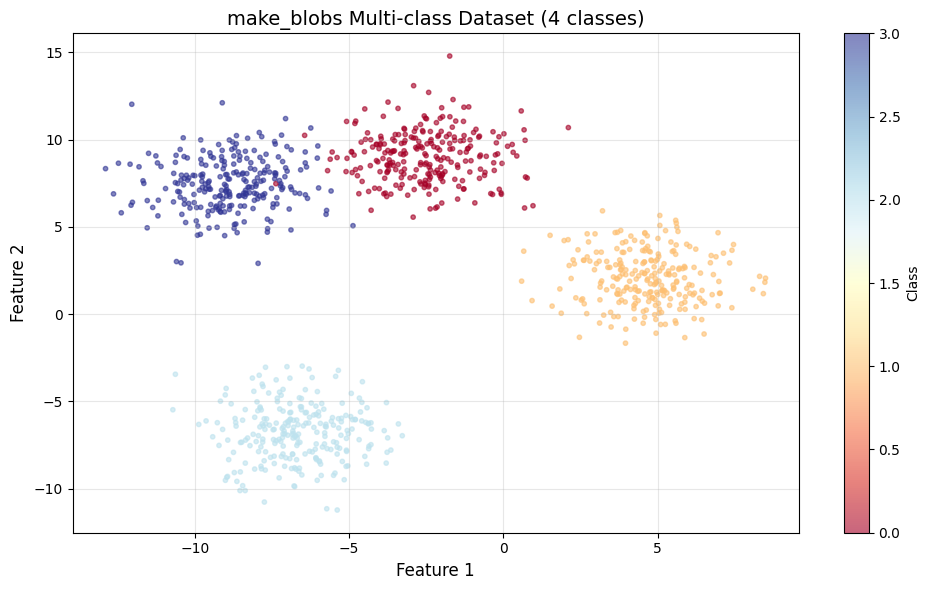

Visualization created!
Motto: Visualize, visualize, visualize!

Part 3: Train/Test Split and Conversion
Training size: 800
Test size: 200

Using device: cpu

Tensor shapes:
X_train: torch.Size([800, 2]), dtype: torch.float32
y_train: torch.Size([800]), dtype: torch.int64
X_test: torch.Size([200, 2]), dtype: torch.float32
y_test: torch.Size([200]), dtype: torch.int64

Part 4: Building Multi-Class Model
BlobModel (Multi-class):
BlobModel(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)

Total parameters: 116

Part 5: Loss Function and Optimizer


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loss function: CrossEntropyLoss()
Optimizer: Adam (lr=0.01)

Key differences from binary:
  - Binary: BCEWithLogitsLoss, y is FloatTensor with shape [N, 1]
  - Multi-class: CrossEntropyLoss, y is LongTensor with shape [N]

Part 6: Training Loop
Epoch [10/100], Loss: 0.4020, Acc: 83.63%
Epoch [20/100], Loss: 0.1678, Acc: 99.25%
Epoch [30/100], Loss: 0.0880, Acc: 98.50%
Epoch [40/100], Loss: 0.0564, Acc: 99.12%
Epoch [50/100], Loss: 0.0426, Acc: 99.12%
Epoch [60/100], Loss: 0.0366, Acc: 99.25%
Epoch [70/100], Loss: 0.0331, Acc: 99.25%
Epoch [80/100], Loss: 0.0307, Acc: 99.25%
Epoch [90/100], Loss: 0.0288, Acc: 99.25%
Epoch [100/100], Loss: 0.0275, Acc: 99.25%

Training complete!

Part 7: Logits → Probabilities → Labels Pipeline

First 3 predictions:

Sample 1:
  Logits: [-5.682291  -4.3854437  5.193898  -3.7657664]
  Probabilities: [1.8898920e-05 6.9127462e-05 9.9978346e-01 1.2846156e-04]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [ 0.6101082  9.1367655 -5.4092436 -8.655636 ]
  Proba

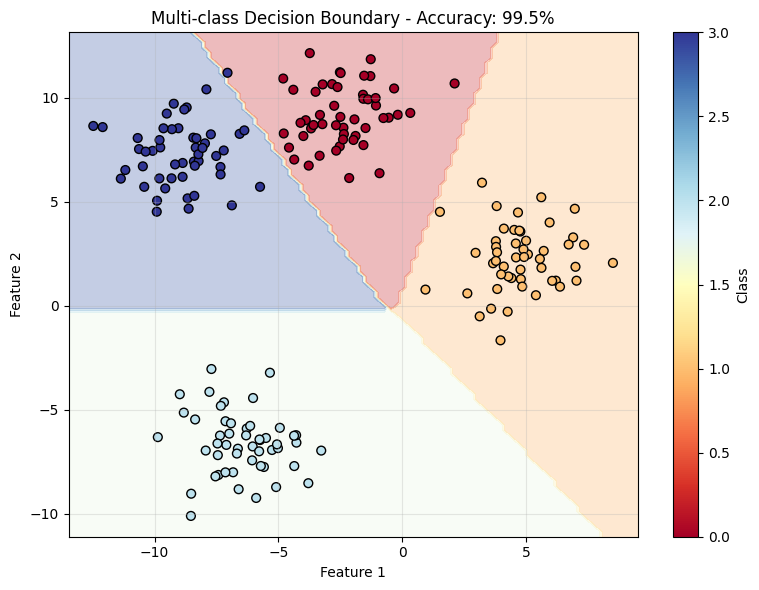


Part 9: Per-Class Accuracy
Class 0 Accuracy: 100.00%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 98.00%

Exercises

Exercise 1: Vary number of classes
Try different numbers of classes:
  - n_classes=2 (binary)
  - n_classes=3
  - n_classes=4 (default)
  - n_classes=5
Tip: Modify the 'n_classes' and 'centers' parameters

Exercise 2: Change cluster overlap
Try different cluster_std values:
  - cluster_std=0.5 (tight clusters)
  - cluster_std=1.5 (default)
  - cluster_std=3.0 (overlapping clusters)
Tip: Modify the 'cluster_std' parameter in make_blobs()

Exercise 3: Compare binary vs multi-class
Questions to answer:
  - How is binary different from multi-class?
  - What's different about the loss function?
  - What's different about the output activation?
Tip: Look at BCEWithLogitsLoss vs CrossEntropyLoss

Exercise 4: Experiment with model size
Try different model sizes:
  - hidden_size=8
  - hidden_size=16 (default)
  - hidden_size=32
Tip: Modify the 'hidden_si

In [1]:
"""
Exercise 4: Multi-Class Classification
Neural Network Classification - Module 3

This exercise covers:
- Creating multi-class data with make_blobs
- Building multi-class models
- Using CrossEntropyLoss
- Converting logits with softmax
- Using argmax for predictions

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Creating make_blobs Dataset
# ============================================

print("=" * 60)
print("Part 1: Creating make_blobs Dataset")
print("=" * 60)

# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 4

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# ============================================
# Part 2: Visualizing the Data
# ============================================

print("\n" + "=" * 60)
print("Part 2: Visualizing the Data")
print("=" * 60)

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

print("Visualization created!")
print("Motto: Visualize, visualize, visualize!")

# ============================================
# Part 3: Train/Test Split and Conversion
# ============================================

print("\n" + "=" * 60)
print("Part 3: Train/Test Split and Conversion")
print("=" * 60)

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"\nTensor shapes:")
print(f"X_train: {X_train.shape}, dtype: {X_train.dtype}")
print(f"y_train: {y_train.shape}, dtype: {y_train.dtype}")
print(f"X_test: {X_test.shape}, dtype: {X_test.dtype}")
print(f"y_test: {y_test.shape}, dtype: {y_test.dtype}")

# ============================================
# Part 4: Building Multi-Class Model
# ============================================

print("\n" + "=" * 60)
print("Part 4: Building Multi-Class Model")
print("=" * 60)

# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=16, num_classes=4):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

print("BlobModel (Multi-class):")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# ============================================
# Part 5: Loss Function and Optimizer
# ============================================

print("\n" + "=" * 60)
print("Part 5: Loss Function and Optimizer")
print("=" * 60)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Loss function: CrossEntropyLoss()")
print(f"Optimizer: Adam (lr=0.01)")

print("\nKey differences from binary:")
print("  - Binary: BCEWithLogitsLoss, y is FloatTensor with shape [N, 1]")
print("  - Multi-class: CrossEntropyLoss, y is LongTensor with shape [N]")

# ============================================
# Part 6: Training Loop
# ============================================

print("\n" + "=" * 60)
print("Part 6: Training Loop")
print("=" * 60)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# ============================================
# Part 7: The Logits → Softmax → Argmax Pipeline
# ============================================

print("\n" + "=" * 60)
print("Part 7: Logits → Probabilities → Labels Pipeline")
print("=" * 60)

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

# ============================================
# Part 8: Decision Boundary Visualization
# ============================================

print("\n" + "=" * 60)
print("Part 8: Decision Boundary Visualization")
print("=" * 60)

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='RdYlBu', edgecolors='k')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

# ============================================
# Part 9: Per-Class Accuracy
# ============================================

print("\n" + "=" * 60)
print("Part 9: Per-Class Accuracy")
print("=" * 60)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Vary number of classes
print("\nExercise 1: Vary number of classes")
print("Try different numbers of classes:")
print("  - n_classes=2 (binary)")
print("  - n_classes=3")
print("  - n_classes=4 (default)")
print("  - n_classes=5")
print("Tip: Modify the 'n_classes' and 'centers' parameters")

# Exercise 2: Change cluster standard deviation
print("\nExercise 2: Change cluster overlap")
print("Try different cluster_std values:")
print("  - cluster_std=0.5 (tight clusters)")
print("  - cluster_std=1.5 (default)")
print("  - cluster_std=3.0 (overlapping clusters)")
print("Tip: Modify the 'cluster_std' parameter in make_blobs()")

# Exercise 3: Compare binary vs multi-class
print("\nExercise 3: Compare binary vs multi-class")
print("Questions to answer:")
print("  - How is binary different from multi-class?")
print("  - What's different about the loss function?")
print("  - What's different about the output activation?")
print("Tip: Look at BCEWithLogitsLoss vs CrossEntropyLoss")

# Exercise 4: Experiment with model size
print("\nExercise 4: Experiment with model size")
print("Try different model sizes:")
print("  - hidden_size=8")
print("  - hidden_size=16 (default)")
print("  - hidden_size=32")
print("Tip: Modify the 'hidden_size' parameter in BlobModel()")

# Exercise 5: Add more hidden layers
print("\nExercise 5: Add more hidden layers")
print("Try deeper architectures:")
print("  - Add another hidden layer")
print("  - Experiment with different widths")
print("Tip: Modify BlobModel to add more layers")

print("\n" + "=" * 60)
print("Exercise 4 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Vary number of classes
Try different numbers of classes:
- n_classes=2 (binary)
- n_classes=3
- n_classes=4 (default)
- n_classes=5

In [2]:
n_classes_list = [2, 3, 5]

for n_classes_new in n_classes_list:
    print(f"\n{'='*60}")
    print(f"Testing with {n_classes_new} classes")
    print(f"{'='*60}")
    
    # Create new dataset
    X_new, y_new = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=n_classes_new,
        cluster_std=1.5,
        random_state=42
    )
    
    # Split and convert
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
    )
    
    X_train_new = torch.FloatTensor(X_train_new).to(device)
    y_train_new = torch.LongTensor(y_train_new).to(device)
    X_test_new = torch.FloatTensor(X_test_new).to(device)
    y_test_new = torch.LongTensor(y_test_new).to(device)
    
    # Create and train model
    model_new = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes_new).to(device)
    criterion_new = nn.CrossEntropyLoss()
    optimizer_new = optim.Adam(model_new.parameters(), lr=0.01)
    
    model_new.train()
    for epoch in range(100):
        y_logits_new = model_new(X_train_new)
        loss = criterion_new(y_logits_new, y_train_new)
        optimizer_new.zero_grad()
        loss.backward()
        optimizer_new.step()
    
    # Evaluate
    model_new.eval()
    with torch.inference_mode():
        test_logits_new = model_new(X_test_new)
        test_preds_new = torch.argmax(test_logits_new, dim=1)
    
    test_acc = (test_preds_new == y_test_new).float().mean()
    print(f"Test Accuracy: {test_acc.item()*100:.2f}%")
    print(f"Number of classes: {n_classes_new}")


Testing with 2 classes
Test Accuracy: 100.00%
Number of classes: 2

Testing with 3 classes
Test Accuracy: 99.50%
Number of classes: 3

Testing with 5 classes
Test Accuracy: 91.50%
Number of classes: 5


# Exercise 2: Change cluster standard deviation
Try different cluster_std values:
- cluster_std=0.5 (tight clusters)
- cluster_std=1.5 (default)
- cluster_std=3.0 (overlapping clusters)

In [3]:
cluster_std_list = [0.5, 1.5, 3.0]

for cluster_std_val in cluster_std_list:
	print(f"\n{'='*60}")
	print(f"Testing with cluster_std={cluster_std_val}")
	print(f"{'='*60}")
	
	# Create dataset with different cluster overlap
	X_std, y_std = make_blobs(
		n_samples=n_samples,
		n_features=2,
		centers=n_classes,
		cluster_std=cluster_std_val,
		random_state=42
	)
	
	# Split and convert
	X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(
		X_std, y_std, test_size=0.2, random_state=42, stratify=y_std
	)
	
	X_train_std = torch.FloatTensor(X_train_std).to(device)
	y_train_std = torch.LongTensor(y_train_std).to(device)
	X_test_std = torch.FloatTensor(X_test_std).to(device)
	y_test_std = torch.LongTensor(y_test_std).to(device)
	
	# Create and train model
	model_std = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes).to(device)
	criterion_std = nn.CrossEntropyLoss()
	optimizer_std = optim.Adam(model_std.parameters(), lr=0.01)
	
	model_std.train()
	for epoch in range(100):
		y_logits_std = model_std(X_train_std)
		loss = criterion_std(y_logits_std, y_train_std)
		optimizer_std.zero_grad()
		loss.backward()
		optimizer_std.step()
	
	# Evaluate
	model_std.eval()
	with torch.inference_mode():
		test_logits_std = model_std(X_test_std)
		test_preds_std = torch.argmax(test_logits_std, dim=1)
	
	test_acc_std = (test_preds_std == y_test_std).float().mean()
	print(f"Test Accuracy: {test_acc_std.item()*100:.2f}%")
	print(f"Cluster std: {cluster_std_val}")


Testing with cluster_std=0.5
Test Accuracy: 100.00%
Cluster std: 0.5

Testing with cluster_std=1.5
Test Accuracy: 99.50%
Cluster std: 1.5

Testing with cluster_std=3.0
Test Accuracy: 91.50%
Cluster std: 3.0


# Exercise 3: Compare binary vs multi-class
Questions to answer:
- How is binary different from multi-class?
- What's different about the loss function?
- What's different about the output activation?

In [5]:
ans = """
1. How is binary different from multi-class?
Binary classification involves only two possible classes (for example, 0 or 1, yes or no). \nThe model learns to decide between these two outcomes. In contrast, multi-class classification involves more than two classes (for example, class A, B, or C). \nInstead of choosing between two options, the model must assign the input to one of several possible categories. This changes how the output layer is structured and how predictions are interpreted.

2. What’s different about the loss function?
For binary classification, we typically use BCEWithLogitsLoss, which combines a sigmoid activation and binary cross-entropy loss in one stable function. \nIt expects a single output value per sample. For multi-class classification, we use CrossEntropyLoss, which combines softmax and negative log-likelihood loss. \nIt expects multiple output logits (one per class) and compares them to the correct class index. \nSo the key difference is that binary loss handles one probability, while multi-class loss handles a probability distribution across multiple classes.

3. What’s different about the output activation?
In binary classification, the model usually applies a sigmoid activation (or uses BCEWithLogitsLoss, which applies sigmoid internally) to produce a probability between 0 and 1. \nIn multi-class classification, the model uses softmax (or relies on CrossEntropyLoss, which applies it internally) to convert logits into probabilities that sum to 1 across all classes. \nSigmoid treats outputs independently, while softmax makes the classes compete against each other.
"""

print(ans)


1. How is binary different from multi-class?
Binary classification involves only two possible classes (for example, 0 or 1, yes or no). 
The model learns to decide between these two outcomes. In contrast, multi-class classification involves more than two classes (for example, class A, B, or C). 
Instead of choosing between two options, the model must assign the input to one of several possible categories. This changes how the output layer is structured and how predictions are interpreted.

2. What’s different about the loss function?
For binary classification, we typically use BCEWithLogitsLoss, which combines a sigmoid activation and binary cross-entropy loss in one stable function. 
It expects a single output value per sample. For multi-class classification, we use CrossEntropyLoss, which combines softmax and negative log-likelihood loss. 
It expects multiple output logits (one per class) and compares them to the correct class index. 
So the key difference is that binary loss handle

# Exercise 4: Experiment with model size
Try different model sizes:
- hidden_size=8
- hidden_size=16 (default)
- hidden_size=32


In [6]:
hidden_size_list = [8, 16, 32]

for hidden_size_val in hidden_size_list:
    print(f"\n{'='*60}")
    print(f"Testing with hidden_size={hidden_size_val}")
    print(f"{'='*60}")
    
    # Create and train model with different hidden size
    model_hs = BlobModel(input_size=2, hidden_size=hidden_size_val, num_classes=n_classes).to(device)
    criterion_hs = nn.CrossEntropyLoss()
    optimizer_hs = optim.Adam(model_hs.parameters(), lr=0.01)
    
    # Count parameters
    total_params_hs = sum(p.numel() for p in model_hs.parameters())
    print(f"Total parameters: {total_params_hs:,}")
    
    model_hs.train()
    for epoch in range(100):
        y_logits_hs = model_hs(X_train)
        loss = criterion_hs(y_logits_hs, y_train)
        optimizer_hs.zero_grad()
        loss.backward()
        optimizer_hs.step()
    
    # Evaluate
    model_hs.eval()
    with torch.inference_mode():
        test_logits_hs = model_hs(X_test)
        test_preds_hs = torch.argmax(test_logits_hs, dim=1)
    
    test_acc_hs = (test_preds_hs == y_test).float().mean()
    print(f"Test Accuracy: {test_acc_hs.item()*100:.2f}%")
    print(f"Hidden size: {hidden_size_val}")


Testing with hidden_size=8
Total parameters: 60
Test Accuracy: 99.50%
Hidden size: 8

Testing with hidden_size=16
Total parameters: 116
Test Accuracy: 99.50%
Hidden size: 16

Testing with hidden_size=32
Total parameters: 228
Test Accuracy: 99.50%
Hidden size: 32


# Exercise 5: Add more hidden layers
Try deeper architectures:
- Add another hidden layer
- Experiment with different widths


In [7]:
class DeepBlobModel(nn.Module):
    def __init__(self, input_size=2, hidden_size_1=16, hidden_size_2=8, num_classes=4):
        super(DeepBlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.ReLU(),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Linear(hidden_size_2, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Test different deeper architectures
architectures = [
    {"hidden_size_1": 16, "hidden_size_2": 8, "name": "16->8"},
    {"hidden_size_1": 32, "hidden_size_2": 16, "name": "32->16"},
    {"hidden_size_1": 32, "hidden_size_2": 8, "name": "32->8"},
]

for arch in architectures:
    print(f"\n{'='*60}")
    print(f"Testing architecture: {arch['name']}")
    print(f"{'='*60}")
    
    # Create deeper model
    model_deep = DeepBlobModel(input_size=2, hidden_size_1=arch["hidden_size_1"], 
                            hidden_size_2=arch["hidden_size_2"], num_classes=n_classes).to(device)
    criterion_deep = nn.CrossEntropyLoss()
    optimizer_deep = optim.Adam(model_deep.parameters(), lr=0.01)
    
    # Count parameters
    total_params_deep = sum(p.numel() for p in model_deep.parameters())
    print(f"Total parameters: {total_params_deep:,}")
    
    # Train
    model_deep.train()
    for epoch in range(100):
        y_logits_deep = model_deep(X_train)
        loss = criterion_deep(y_logits_deep, y_train)
        optimizer_deep.zero_grad()
        loss.backward()
        optimizer_deep.step()
    
    # Evaluate
    model_deep.eval()
    with torch.inference_mode():
        test_logits_deep = model_deep(X_test)
        test_preds_deep = torch.argmax(test_logits_deep, dim=1)
    
    test_acc_deep = (test_preds_deep == y_test).float().mean()
    print(f"Test Accuracy: {test_acc_deep.item()*100:.2f}%")
    print(f"Architecture: {arch['hidden_size_1']}->{arch['hidden_size_2']}")


Testing architecture: 16->8
Total parameters: 220
Test Accuracy: 99.50%
Architecture: 16->8

Testing architecture: 32->16
Total parameters: 692
Test Accuracy: 99.50%
Architecture: 32->16

Testing architecture: 32->8
Total parameters: 396
Test Accuracy: 99.50%
Architecture: 32->8
